# 01 — Getting to know the data (Part 1)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from db import run_query, run_sql_file, close
from style import BLUE, ORANGE, AQUA, INK_2, MUTED, GREYS, SALE, save

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

## 0. Data quality

In [2]:
dq = run_sql_file("01_data_quality.sql")
(row_counts, join_check, survivors, dup_ids, refunds, pre_install,
 hour_ranges, ad_hours, ad_day_match, cap_changes, coverage_gaps,
 no_active_row, device_links, cs_outliers, cs_typical, install_mix, first_activity) = dq

display(row_counts)
display(survivors)
display(dup_ids)
display(refunds)

,table_name,n_rows,n_keys
0,player_profile,80295,80295
1,player_day,667435,667435
2,purchase,15426,15304


,grp,players,first_install,last_install,share_active_in_window
0,installed in window,64295,2026-01-01,2026-04-30,0.9842
1,installed before window,16000,2025-05-27,2025-12-31,0.9938


,duplicated_ids,extra_rows,extra_usd,ids_with_identical_fields,ids_logged_same_day
0,122,122.0,1815.82,122.0,122.0


,refund_rows,refund_usd,matched_to_earlier_purchase
0,226,-3249.74,222.0


,table_name,min_hour,max_hour
0,purchase,6,23
1,currency_spend,6,23
2,ad_view (raw),0,23


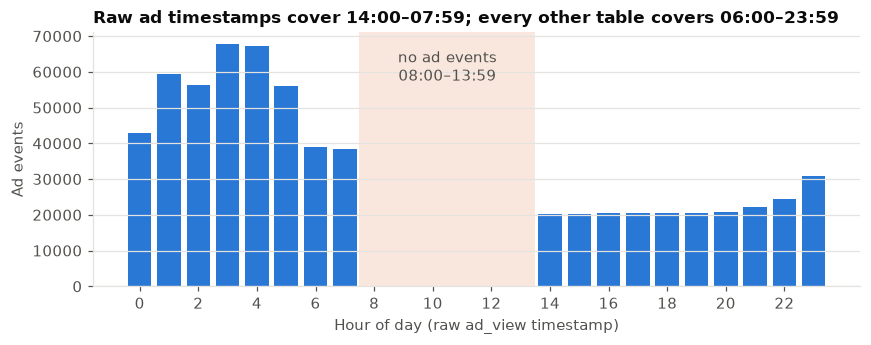

In [3]:
display(hour_ranges)

fig, ax = plt.subplots(figsize=(9, 3))
hours = pd.DataFrame({"hour": range(24)}).merge(ad_hours.rename(columns={"hour_raw": "hour"}), how="left").fillna(0)
ax.bar(hours["hour"], hours["ad_events"], color=BLUE, width=0.8)
ax.axvspan(7.5, 13.5, color=SALE, alpha=0.6, lw=0)
ax.text(10.5, hours["ad_events"].max() * 0.85, "no ad events\n08:00–13:59", ha="center", color=INK_2)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day (raw ad_view timestamp)")
ax.set_ylabel("Ad events")
ax.set_title("Raw ad timestamps cover 14:00–07:59; every other table covers 06:00–23:59")
save(fig, "dq_ad_hours")
plt.show()

In [4]:
display(ad_day_match)
display(cap_changes)

,version,ad_player_days,no_matching_active_day
0,raw ad timestamps,463952,236142.0
1,shifted -8h,392949,0.0


,version,player_days_with_2_caps
0,raw day boundary,8212
1,local day boundary,0


In [5]:
display(coverage_gaps)

,dt,active_rows,purchases,ad_events
0,2026-03-05,4994,56,0
1,2026-03-06,4979,52,0


In [6]:
display(no_active_row)
display(device_links)
display(cs_outliers)
display(install_mix)

,gross_purchases,no_active_row,usd_no_active_row
0,15078,2449.0,35732.51


,linked_players,linked_to_self,different_country,different_platform,installed_before_original
0,3211,1.0,3025.0,1348.0,1584.0


,spend_events_over_50k,devices,max_value
0,232,36,75809670


,install_week,installs,organic_share,paid_video_share,tier4_share
0,2025-12-29,1229,0.456,0.164,0.186
1,2026-01-05,2199,0.466,0.141,0.197
2,2026-01-12,2266,0.453,0.159,0.187
3,2026-01-19,2234,0.457,0.146,0.156
4,2026-01-26,2193,0.456,0.145,0.188
5,2026-02-02,2335,0.448,0.152,0.185
6,2026-02-09,2262,0.444,0.155,0.188
7,2026-02-16,2269,0.431,0.172,0.202
8,2026-02-23,2744,0.367,0.295,0.306
9,2026-03-02,3241,0.322,0.404,0.391


### Data Quality Interpretation

1. 122 purchase IDs are duplicated in the raw purchase table and are
   deduplicated in `purchase_clean`.
2. 228 negative purchase transactions are present in the raw data; these
   are retained separately from positive purchase revenue.
3. The rewarded-ad timestamps show a consistent 8-hour offset relative to
   the other activity tables. The corrected `ad_view_local` timestamps
   align ad player-days with `player_day` and remove the apparent
   within-day cap changes.
4. 16,000 players were installed before the study window and are treated
   as existing/survivor players, not new-install cohorts.
5. Some purchases occur on dates where the buyer has no `player_day` row;
   the revenue is retained, while daily payer share uses active buyers.
6. `original_device_id` links are not reliable enough for player merging,
   so each `device_id` is analysed as its own player.
7. A small set of currency-spend records are highly anomalous and are
   excluded from economy analysis.
8. Install volume and player mix change substantially over the study
   period, so pooled comparisons need to account for composition.
9. Ad telemetry is missing on 2026-03-05 and 2026-03-06 after timestamp
   correction and is treated as missing data rather than zero engagement.
10. Some players first appear in `player_day` after their recorded install
    date, which is an important limitation when interpreting D1 retention.

**Overall:** the main data-quality issues are identified and handled
explicitly before the downstream analysis.

## 1(a) Daily health by platform

In [7]:
dh = run_sql_file("02_daily_health.sql")
daily, reconciliation, platform_period, coverage = dh
daily["date"] = pd.to_datetime(daily["date"])
display(daily.head(9))
display(reconciliation)
display(platform_period)

,date,platform,dau,gross_revenue,arpdau,active_payers,payer_share
0,2026-01-01,All,1789.0,714.55,0.3994,45.0,0.0252
1,2026-01-01,Android,1118.0,482.79,0.4318,21.0,0.0188
2,2026-01-01,iOS,671.0,231.76,0.3454,24.0,0.0358
3,2026-01-02,All,1927.0,758.57,0.3937,43.0,0.0223
4,2026-01-02,Android,1239.0,316.80,0.2557,20.0,0.0161
5,2026-01-02,iOS,688.0,441.77,0.6421,23.0,0.0334
6,2026-01-03,All,1968.0,571.60,0.2904,40.0,0.0203
7,2026-01-03,Android,1275.0,214.81,0.1685,19.0,0.0149
8,2026-01-03,iOS,693.0,356.79,0.5148,21.0,0.0303


,gross_total_table,gross_total_joined,refunds_total,net_total,raw_table_total,player_days_table
0,217593.22,217593.22,-3249.74,214343.48,216159.3,667435


,platform,player_days,gross_revenue,arpdau
0,iOS,208857,104484.98,0.5003
1,Android,458578,113108.24,0.2466


In [8]:
# Cross-check: the platform rows add up to the 'All' row every day.
wide = daily.pivot(index="date", columns="platform", values=["dau", "gross_revenue", "active_payers"])
for m in ["dau", "gross_revenue", "active_payers"]:
    diff = (wide[(m, "Android")] + wide[(m, "iOS")] - wide[(m, "All")]).abs().max()
    print(f"{m:15s} max |Android + iOS - All| = {diff:.6f}")
print("sum of daily gross revenue:", round(wide[("gross_revenue", "All")].sum(), 2))

dau             max |Android + iOS - All| = 0.000000
gross_revenue   max |Android + iOS - All| = 0.000000
active_payers   max |Android + iOS - All| = 0.000000
sum of daily gross revenue: 217593.22


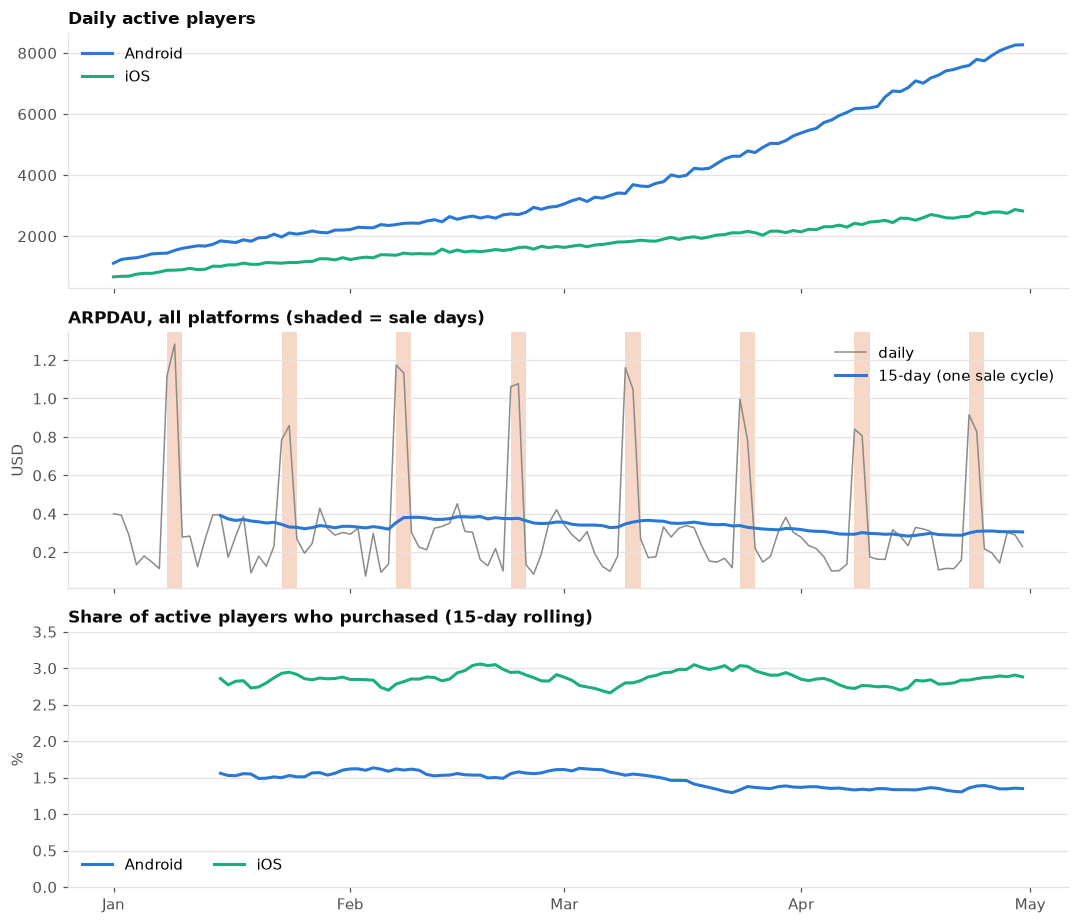

In [9]:
allp = daily[daily.platform == "All"].set_index("date")
sale_days = run_query("""
    SELECT DISTINCT event_dt AS dt FROM purchase_clean WHERE sale_flag = 1 AND usd_amount > 0
""")["dt"].pipe(pd.to_datetime)

fig, axes = plt.subplots(3, 1, figsize=(10, 8.5), sharex=True)
ax = axes[0]
for plat, col in [("Android", BLUE), ("iOS", AQUA)]:
    s = daily[daily.platform == plat].set_index("date")["dau"]
    ax.plot(s.index, s, color=col, label=plat)
ax.set_title("Daily active players")
ax.legend(loc="upper left")

ax = axes[1]
for d in sale_days:
    ax.axvspan(d, d + pd.Timedelta(days=1), color=SALE, lw=0)
ax.plot(allp.index, allp["arpdau"], color=MUTED, lw=1, label="daily")
roll = allp["gross_revenue"].rolling(15).sum() / allp["dau"].rolling(15).sum()
ax.plot(roll.index, roll, color=BLUE, label="15-day (one sale cycle)")
ax.set_title("ARPDAU, all platforms (shaded = sale days)")
ax.set_ylabel("USD")
ax.legend(loc="upper right")

ax = axes[2]
for plat, col in [("Android", BLUE), ("iOS", AQUA)]:
    s = daily[daily.platform == plat].set_index("date")
    r = s["active_payers"].rolling(15).sum() / s["dau"].rolling(15).sum()
    ax.plot(r.index, r * 100, color=col, label=plat)
ax.set_title("Share of active players who purchased (15-day rolling)")
ax.set_ylabel("%")
ax.set_ylim(0, 3.5)
ax.legend(loc="lower left", ncol=2)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.tight_layout()
save(fig, "p1_daily_health")
plt.show()

### ## 1(a) Daily health by platform Interpretation

1. DAU increases from 1,789 on January 1 to 11,097 on April 30.
2. Over the full period, iOS has higher ARPDAU than Android
   (approximately $0.50 vs $0.25).
3. Gross in-app purchase revenue is $217,593.22; negative transactions
   total -$3,249.74, giving net observed purchase revenue of $214,343.48.
4. Daily revenue reconciles to the cleaned purchase table, and all 120
   analysis days contain player activity.
5. Daily ARPDAU shows recurring spikes around the observed promotion
   cadence, so period comparisons should account for sale timing.

**Action:** use player-days for multi-day ARPDAU, keep refunds separate
from positive purchase revenue, and interpret blended monetization together
with platform and player-mix changes.

## 1(b) Retention by install week


In [10]:
retention, retention_summary = run_sql_file("03_retention.sql")
retention["install_week"] = pd.to_datetime(retention["install_week"]).dt.strftime("%d %b")
grid = retention.set_index("install_week")
display(grid.style.format({c: "{:.1%}" for c in grid.columns if c != "cohort_size"}, na_rep="—"))
display(retention_summary)

,cohort_size,d1_retention,d7_retention,d14_retention,d30_retention
install_week,,,,,
29 Dec,1229,46.0%,24.2%,18.9%,12.8%
05 Jan,2199,46.5%,26.8%,19.1%,13.7%
12 Jan,2266,47.8%,26.2%,19.9%,15.0%
19 Jan,2234,47.7%,24.5%,18.6%,12.7%
26 Jan,2193,47.5%,25.9%,21.4%,14.8%
02 Feb,2335,48.0%,26.9%,20.8%,14.6%
09 Feb,2262,50.4%,25.2%,19.7%,14.6%
16 Feb,2269,47.2%,23.9%,19.5%,14.5%
23 Feb,2744,46.9%,26.8%,19.0%,14.1%


,milestone,retention,eligible_installs
0,D1,0.4764,63353
1,D7,0.2540,57637
2,D14,0.1953,51151
3,D30,0.1388,37489


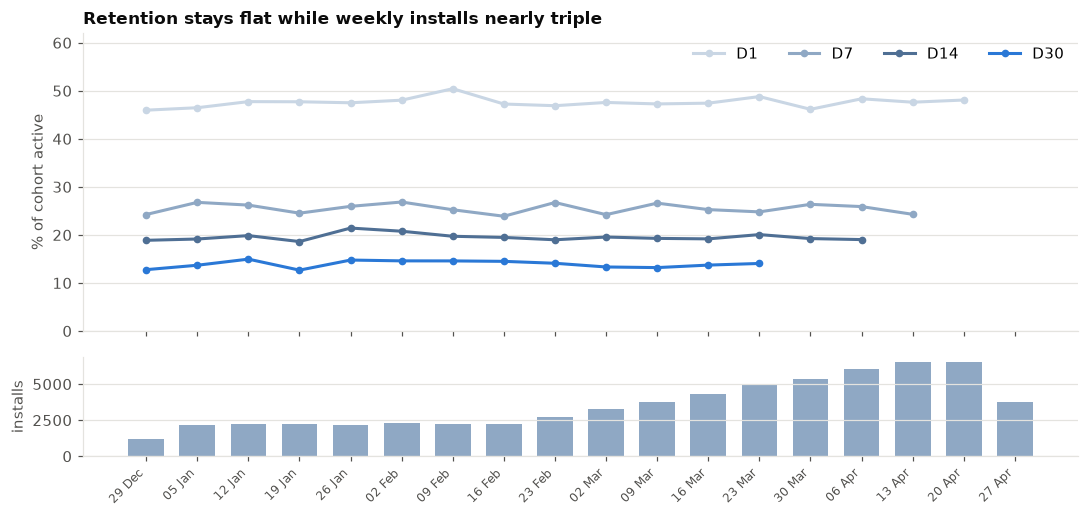

In [11]:
fig, (ax, axb) = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
x = np.arange(len(grid))
for col, lab, c in [("d1_retention", "D1", GREYS[3]), ("d7_retention", "D7", GREYS[2]),
                    ("d14_retention", "D14", GREYS[1]), ("d30_retention", "D30", BLUE)]:
    ax.plot(x, grid[col] * 100, marker="o", ms=4, color=c, label=lab)
ax.set_ylim(0, 62)
ax.set_ylabel("% of cohort active")
ax.set_title("Retention stays flat while weekly installs nearly triple")
ax.legend(ncol=4, loc="upper right")
axb.bar(x, grid["cohort_size"], color=GREYS[2], width=0.7)
axb.set_ylabel("installs")
axb.set_xticks(x); axb.set_xticklabels(grid.index, rotation=45, ha="right", fontsize=8)
fig.tight_layout()
save(fig, "p1_retention")
plt.show()

### 1(b) Retention by install week Interpretation

1. Player-weighted retention is approximately 47% at D1, 25% at D7,
   20% at D14 and 14% at D30.
2. Retention remains broadly stable across the fully observable install
   cohorts.
3. Recent cohorts are shown as NULL where the required milestone is not
   yet fully observable; NULL is not treated as zero retention.
4. Some players first appear in `player_day` after their recorded install
   date, so D1 should be interpreted with this data-quality limitation in
   mind.
5. Pre-window survivor players are excluded from install-based retention
   analysis.

**Action:** compare cohorts only at fully observable milestones and use
the recorded `install_date` as the retention anchor.

## 1(c) Spender behaviour

In [12]:
concentration, ttfp_buckets, ttfp_pct, conversion_curve, gap_pct, gap_buckets = run_sql_file("04_spender_behaviour.sql")
display(concentration)
display(ttfp_buckets)
display(ttfp_pct)
display(conversion_curve)
display(gap_pct)
display(gap_buckets)

,ranked_population,players,top_1pct_share,top_10pct_share,top_50pct_share
0,payers only,11054,0.0922,0.4764,0.8994
1,everyone,80295,0.3997,0.9666,1.0000


,bucket,installs,share_of_installs
0,day 0,473,0.0126
1,days 1-3,766,0.0204
2,days 4-7,798,0.0213
3,days 8-14,961,0.0256
4,days 15-29,1436,0.0383
5,no purchase by day 29,33055,0.8817


,payers_within_30d,p25_days,median_days,p75_days,p90_days
0,4434,3,9,17,24


,by_day,eligible_installs,share_paid
0,0,64295,0.0116
1,3,61473,0.0307
2,7,57637,0.0510
3,14,51151,0.0763
4,30,37489,0.1206
5,60,19731,0.1860
6,90,9494,0.2264


,repeat_purchases,repeat_buyers,p10_days,p25_days,median_days,p75_days,p90_days
0,4024,2476,1.9,6.4,15.3,32.8,54.8


,gap_bucket,repeat_purchases,share
0,< 1 day,244,0.0606
1,1-3,465,0.1156
2,4-7,522,0.1297
3,8-13,600,0.1491
4,14-16 (one sale cycle),343,0.0852
5,17-30,764,0.1899
6,31-60,781,0.1941
7,61+,305,0.0758


In [13]:
# Cross-check 4A in pandas from raw rows
rev = run_query("""
    SELECT p.device_id, COALESCE(SUM(pc.usd_amount), 0) AS gross
    FROM player_profile p
    LEFT JOIN purchase_clean pc ON pc.device_id = p.device_id AND pc.usd_amount > 0
    GROUP BY p.device_id
""")
payers = rev[rev.gross > 0].sort_values("gross", ascending=False)
for pct in (0.01, 0.10, 0.50):
    n = int(np.ceil(len(payers) * pct))
    print(f"top {pct:.0%} of payers: {payers.gross.iloc[:n].sum() / payers.gross.sum():.2%}")

top 1% of payers: 9.22%
top 10% of payers: 47.64%
top 50% of payers: 89.94%


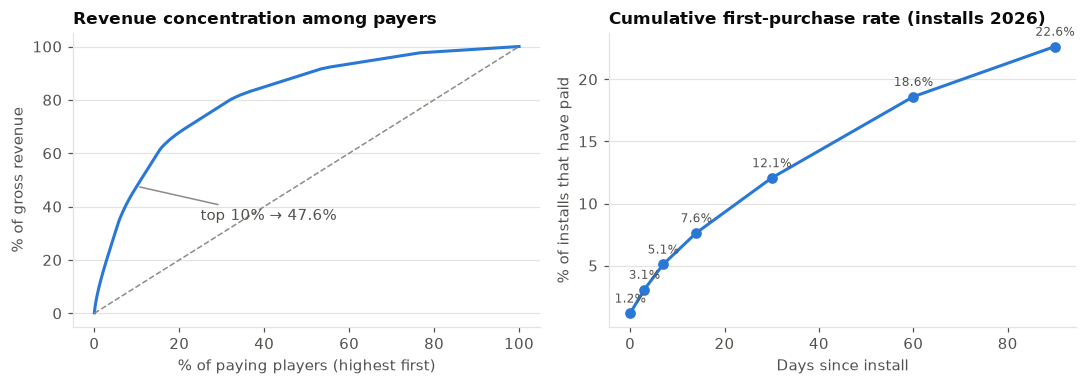

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
ax = axes[0]
cum = payers.gross.cumsum() / payers.gross.sum()
ax.plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum * 100, color=BLUE)
ax.plot([0, 100], [0, 100], color=MUTED, lw=1, ls="--")
ax.set_xlabel("% of paying players (highest first)")
ax.set_ylabel("% of gross revenue")
ax.set_title("Revenue concentration among payers")
ax.annotate("top 10% → 47.6%", xy=(10, 47.6), xytext=(25, 35), color=INK_2,
            arrowprops=dict(arrowstyle="-", color=MUTED))

ax = axes[1]
cc = conversion_curve
ax.plot(cc["by_day"], cc["share_paid"] * 100, marker="o", color=BLUE)
for _, r in cc.iterrows():
    ax.annotate(f"{r.share_paid:.1%}", (r.by_day, r.share_paid * 100), textcoords="offset points",
                xytext=(0, 7), ha="center", fontsize=8, color=INK_2)
ax.set_xlabel("Days since install")
ax.set_ylabel("% of installs that have paid")
ax.set_title("Cumulative first-purchase rate (installs 2026)")
fig.tight_layout()
save(fig, "p1_spenders")
plt.show()

### 1(c) Spender behaviour Interpretation

1. Among payers, the top 1%, 10% and 50% account for approximately
   9.2%, 47.6% and 89.9% of gross revenue respectively.
2. Revenue concentration is much higher when the full player base is
   ranked because most players do not make a purchase.
3. Among January-March installs, 11.8% make a purchase within their first
   30 days.
4. Among players who pay within 30 days, the median first purchase occurs
   on day 9, with an IQR of 3-17 days.
5. The share of players who have paid continues to increase beyond day 30,
   so "never pays" is dependent on the observation horizon.
6. There are 4,024 repeat purchases from 2,476 repeat buyers, with a
   median gap of 15.3 days between consecutive purchases.

**Action:** use the payer population to study monetization behaviour,
use a fixed 30-day horizon for first-purchase comparisons, and treat the
observed roughly two-week repeat cadence as a pattern rather than evidence
of a causal promotion effect.

## 1(d) Rewarded-ad engagement (local time)

In [15]:
cap_table, cap_checks, ad_daily, placements, ad_per_dau = run_sql_file("05_ad_engagement.sql")
display(cap_table)
display(cap_checks)
display(placements)
display(ad_per_dau)

,cap,ad_player_days,hit_cap_days,hit_cap_share,hit_cap_share_completed_only,avg_interactions_per_day,share_with_5plus
0,5,294861,3756.0,0.0127,0.0048,1.648,0.0127
1,8,98088,18.0,0.0002,0.0000,1.649,0.0127


,days_with_two_caps,share_days_counter_equals_rows,players_seen_with_both_caps
0,0,1.0,45551


,placement,interactions,players,completion_rate
0,speedup_offer,129734,51148,0.8197
1,event_boost,129637,51132,0.8201
2,currency_topup,129621,51268,0.8202
3,reward_wheel,129599,51316,0.8205
4,home_banner_optin,129032,51044,0.8197


,period,completed_views_per_dau
0,Jan,0.751
1,Apr,0.852


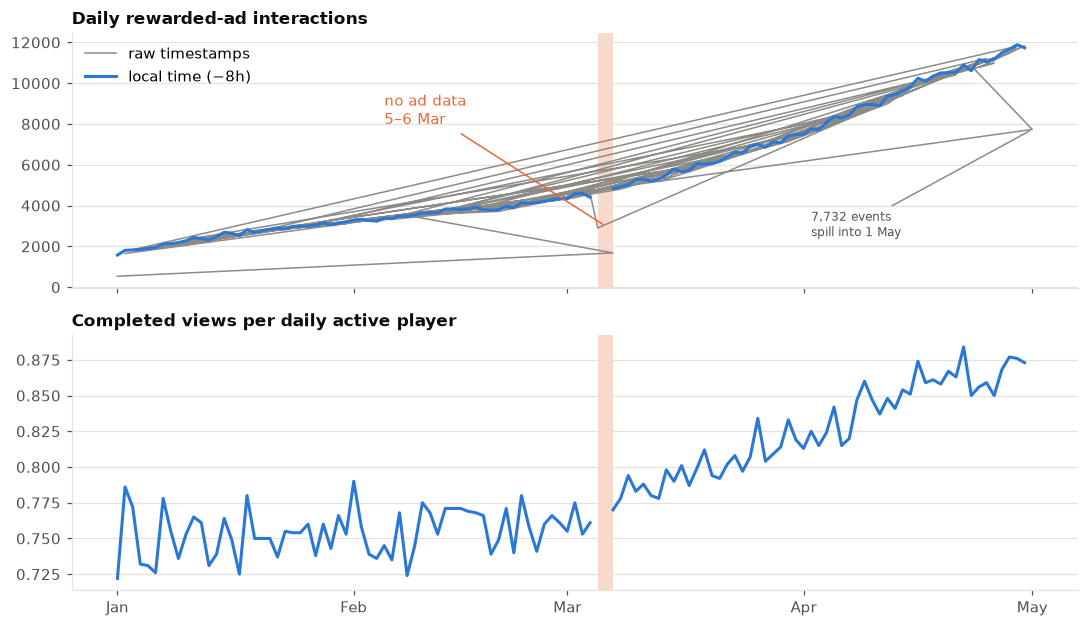

In [16]:
ad_daily["date"] = pd.to_datetime(ad_daily["date"])
raw_daily = run_query("""
    SELECT DATE(event_ts) AS date, COUNT(*) AS interactions FROM ad_view GROUP BY DATE(event_ts)
""")
raw_daily["date"] = pd.to_datetime(raw_daily["date"])

fig, axes = plt.subplots(2, 1, figsize=(10, 5.8), sharex=True)
ax = axes[0]
ax.plot(raw_daily["date"], raw_daily["interactions"], color=MUTED, lw=1, label="raw timestamps")
ax.plot(ad_daily["date"], ad_daily["interactions"], color=BLUE, label="local time (−8h)")
ax.axvspan(pd.Timestamp("2026-03-05"), pd.Timestamp("2026-03-07"), color=ORANGE, alpha=0.25, lw=0)
ax.annotate("no ad data\n5–6 Mar", xy=(pd.Timestamp("2026-03-06"), 3000), xytext=(pd.Timestamp("2026-02-05"), 8000),
            color=ORANGE, arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.annotate("7,732 events\nspill into 1 May", xy=(pd.Timestamp("2026-05-01"), 7732),
            xytext=(pd.Timestamp("2026-04-02"), 2500), color=INK_2, fontsize=8,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_title("Daily rewarded-ad interactions")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(ad_daily["date"], ad_daily["completed_views_per_dau"], color=BLUE)
ax.axvspan(pd.Timestamp("2026-03-05"), pd.Timestamp("2026-03-07"), color=ORANGE, alpha=0.25, lw=0)
ax.set_title("Completed views per daily active player")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.tight_layout()
save(fig, "p1_ads_daily")
plt.show()

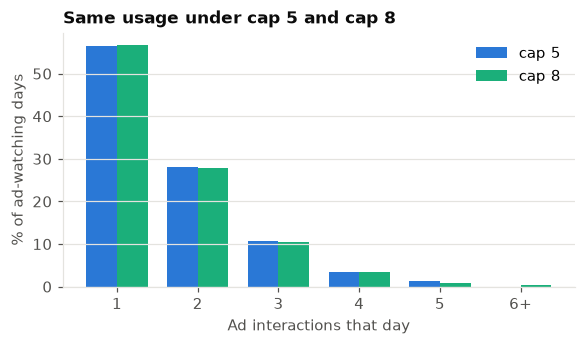

In [17]:
fig, ax = plt.subplots(figsize=(6, 3))
dist = run_query("""
    SELECT cap, LEAST(n, 6) AS n, COUNT(*) AS days
    FROM (SELECT device_id, event_dt, MAX(ad_daily_cap) AS cap, COUNT(*) AS n
          FROM ad_view_local GROUP BY device_id, event_dt) x
    GROUP BY cap, LEAST(n, 6)
""")
dist["share"] = dist.groupby("cap")["days"].transform(lambda s: s / s.sum())
w = 0.38
for i, (cap, col) in enumerate([(5, BLUE), (8, AQUA)]):
    d = dist[dist.cap == cap].sort_values("n")
    ax.bar(d["n"] + (i - 0.5) * w, d["share"] * 100, width=w, color=col, label=f"cap {cap}")
ax.set_xticks(range(1, 7)); ax.set_xticklabels(["1", "2", "3", "4", "5", "6+"])
ax.set_xlabel("Ad interactions that day")
ax.set_ylabel("% of ad-watching days")
ax.set_title("Same usage under cap 5 and cap 8")
ax.legend()
save(fig, "p1_ads_cap")
plt.show()

###  1(d) Rewarded-ad engagement (local time) Interpretation

1. Only 1.27% of cap-5 player-days reach the cap and about 0.02% of
   cap-8 player-days reach the cap.
2. Average ad interactions are essentially identical for cap-5 and cap-8
   player-days at 1.65 interactions per day.
3. Completed ad views per DAU increase from 0.75 in January to 0.85 in
   April.
4. Ad telemetry is missing on March 5-6 while the other activity tables
   continue to report data; these dates are treated as missing telemetry.
5. Placement completion rates are broadly similar across placements.
6. The corrected local-time analysis removes the apparent May 1 spillover
   and within-day cap changes seen under raw timestamps.
7. `reward_amount` represents in-game currency and is not treated as
   advertising revenue.

**Action:** the telemetry does not indicate that the configured cap is a
binding constraint on typical ad usage. Confirm how cap values are assigned
before treating cap 5 vs cap 8 as a clean comparison, exclude the two
outage days from trend comparisons, and validate any cap or placement
change through an experiment.

In [18]:
close()